In [1]:
from rapidfuzz import fuzz
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Amazon Sale Report.csv', encoding = 'unicode escape', low_memory= False)

In [3]:
df.shape

(128975, 24)

In [4]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [7]:
df.head(50)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,...,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,...,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,...,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,...,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,...,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


## --> Start Data Cleaning

In [8]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [9]:
df['city_upper'] = df['ship-city'].str.strip().str.upper()

counts = df['city_upper'].value_counts()
REFERENCE_CITIES = counts[counts >= 20].index.tolist()

def fix_city(city, threshold=88):
    if city in REFERENCE_CITIES:
        return city
    best_match = max(REFERENCE_CITIES, key=lambda ref: fuzz.ratio(city, ref))
    score = fuzz.ratio(city, best_match)
    return best_match if score >= threshold else city

df['ship_city_clean'] = df['city_upper'].apply(fix_city)

In [10]:
df['state_upper'] = df['ship-state'].str.strip().str.upper().str.split('/').str[0].str.strip()

ABBR_MAP = {'RJ': 'RAJASTHAN', 'PB': 'PUNJAB', 'NL': 'NAGALAND', 'AR': 'ARUNACHAL PRADESH',
            'ORISSA': 'ODISHA', 'PONDICHERRY': 'PUDUCHERRY', 'NEW DELHI': 'DELHI'}
df['state_upper'] = df['state_upper'].replace(ABBR_MAP)

REFERENCE_STATES = df['state_upper'].value_counts().pipe(lambda c: c[c >= 10]).index.tolist()

def fix_state(state, threshold=88):
    if state in REFERENCE_STATES:
        return state
    best_match = max(REFERENCE_STATES, key=lambda ref: fuzz.ratio(state, ref))
    return best_match if fuzz.ratio(state, best_match) >= threshold else state

df['ship_state_clean'] = df['state_upper'].apply(fix_state)

In [11]:
df.drop(['promotion-ids', 'Unnamed: 22', 'city_upper', 'state_upper'], axis = 1, inplace= True)

In [12]:
str_blank = [
'Courier Status',
'currency',
'ship-city',
'ship-state',
'ship-country',
'fulfilled-by',
'ship_city_clean',
'ship_state_clean'
]

for bars in str_blank:
    df[bars] = df[bars].fillna(df[bars].mode()[0])

In [13]:
int_blank = [
    'Amount',
    'ship-postal-code'
]

for bar in int_blank:
    df[bar] = df[bar].fillna(df[bar].median())

In [14]:
df.isnull().sum()

index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
fulfilled-by          0
ship_city_clean       0
ship_state_clean      0
dtype: int64

In [15]:
df[['Qty','Amount']].describe()

,Qty,Amount
count,128975.000000,128975.000000
mean,0.904431,645.928694
std,0.313354,272.778829
min,0.000000,0.000000
25%,1.000000,459.000000
50%,1.000000,605.000000
75%,1.000000,771.000000
max,15.000000,5584.000000


In [16]:
df.head(50)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,ship_city_clean,ship_state_clean
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,MUMBAI,MAHARASHTRA
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,BENGALURU,KARNATAKA
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,Easy Ship,NAVI MUMBAI,MAHARASHTRA
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,PUDUCHERRY,PUDUCHERRY
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,Easy Ship,CHENNAI,TAMIL NADU
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,...,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,False,Easy Ship,GHAZIABAD,UTTAR PRADESH
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,...,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,False,Easy Ship,CHANDIGARH,CHANDIGARH
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,...,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,False,Easy Ship,HYDERABAD,TELANGANA
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,...,INR,605.00,HYDERABAD,TELANGANA,500008.0,IN,False,Easy Ship,HYDERABAD,TELANGANA
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,...,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,False,Easy Ship,CHENNAI,TAMIL NADU


## -->Let's Start Analysis

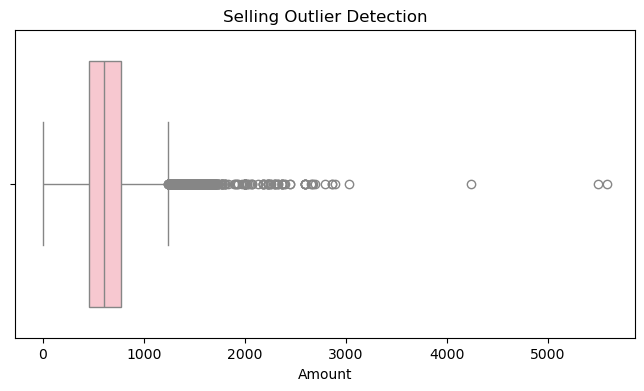

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'], color= 'pink')
plt.title('Selling Outlier Detection')
plt.show()

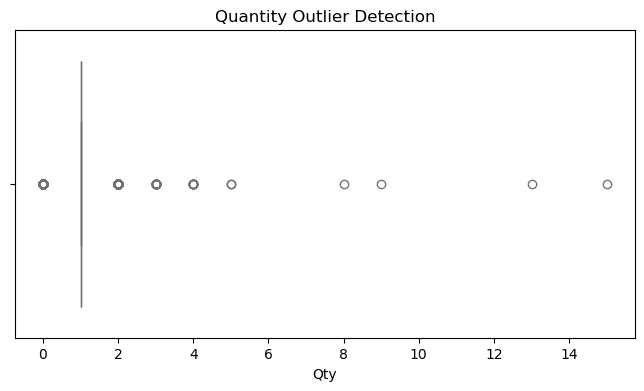

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(x= df['Qty'], color='lightgreen')
plt.title('Quantity Outlier Detection')
plt.show()

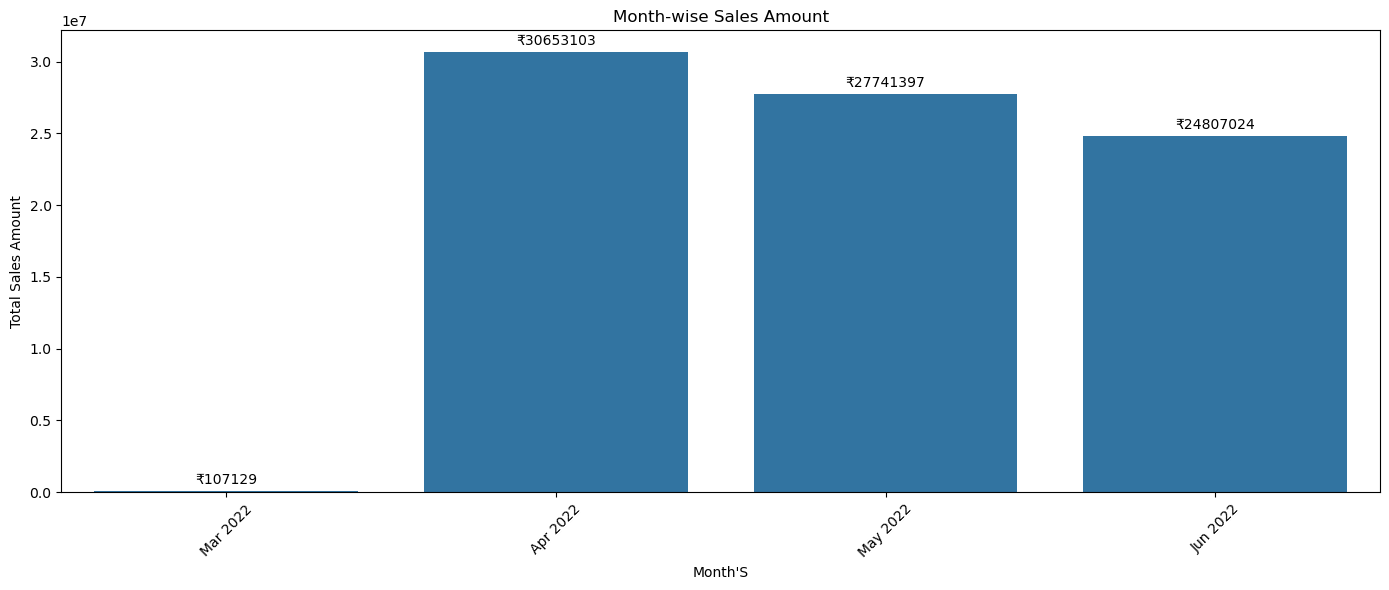

In [57]:
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
df['Month'] = df['Date'].dt.strftime('%b %Y')
month_wise = (df.groupby('Month', as_index=False)['Amount'].sum())

month_order = sorted(df['Date'].dt.to_period('M').unique())
month_wise['Month_period'] = pd.to_datetime(month_wise['Month'], format='%b %Y')

month_wise = month_wise.sort_values('Month_period')
plt.figure(figsize=(14, 6))
ax = sns.barplot(x='Month',y='Amount',data=month_wise)
for container in ax.containers:
    ax.bar_label(container,fmt='₹%.0f',padding=3)
plt.title('Month-wise Sales Amount')
plt.xlabel('Month\'S')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

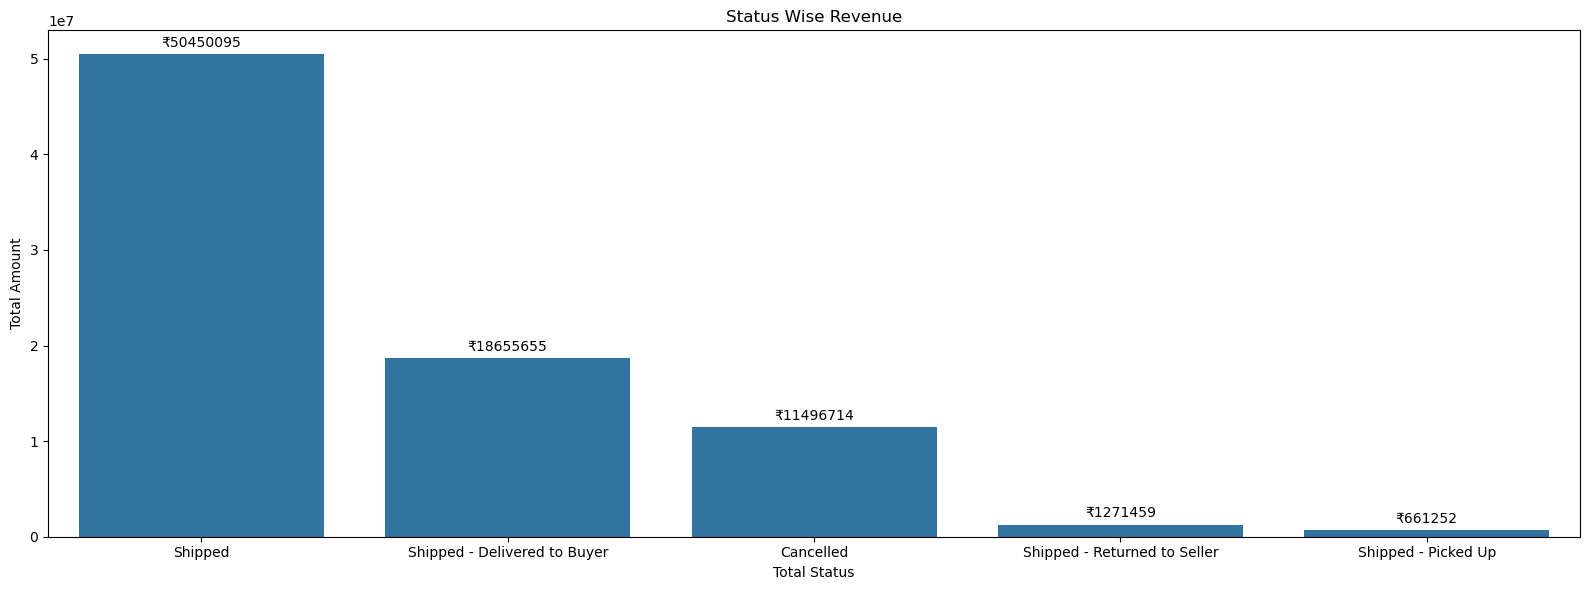

In [58]:
plt.figure(figsize=(16,6))
Status_wise_sales = df.groupby(['Status'], as_index=False)['Amount'].sum().sort_values(by = 'Amount', ascending=False).head(5)
ax = sns.barplot(x= 'Status', y= 'Amount', data= Status_wise_sales)
for container in ax.containers:
    ax.bar_label(container, fmt= '₹%.0f', padding= 3)
plt.title('Status Wise Revenue')
plt.xlabel('Total Status')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

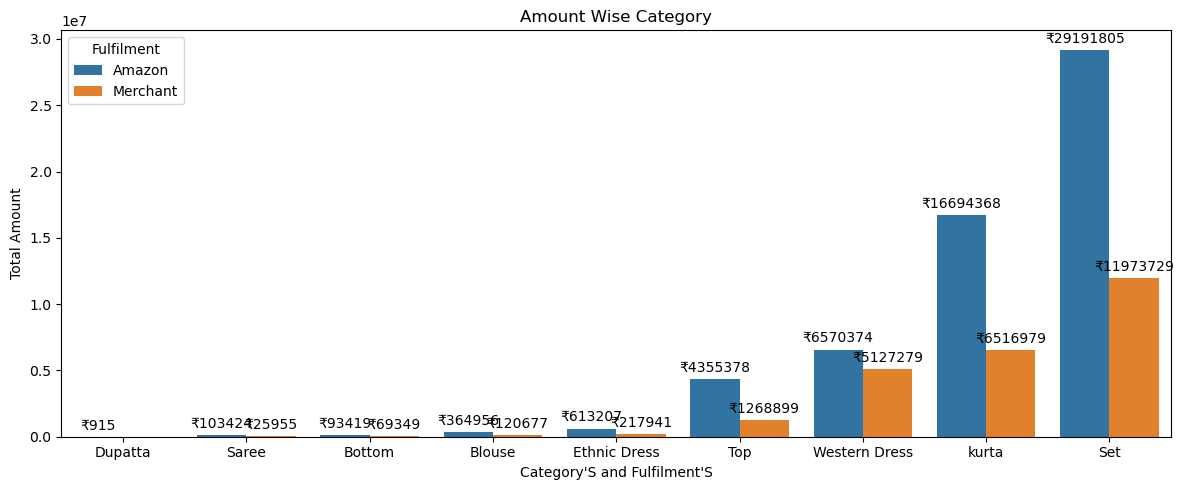

In [21]:
plt.figure(figsize = (12,5))
Sales_platform = df.groupby(['Fulfilment', 'Category'], as_index= False)['Amount'].sum().sort_values(by = 'Amount', ascending=True)
ax = sns.barplot(x= 'Category', y='Amount', hue= 'Fulfilment', data = Sales_platform)
for container in ax.containers:
    ax.bar_label(container, fmt= '₹%.0f', padding =3)
plt.title('Amount Wise Category')
plt.xlabel('Category\'S and Fulfilment\'S')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

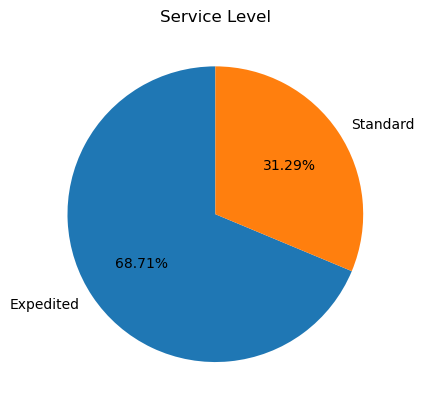

In [22]:
count_ship_service = df['ship-service-level'].value_counts()
plt.pie(
    count_ship_service,
    labels = count_ship_service.index,
    autopct = '%1.2f%%',
    startangle = 90
)
plt.title('Service Level')
plt.show()

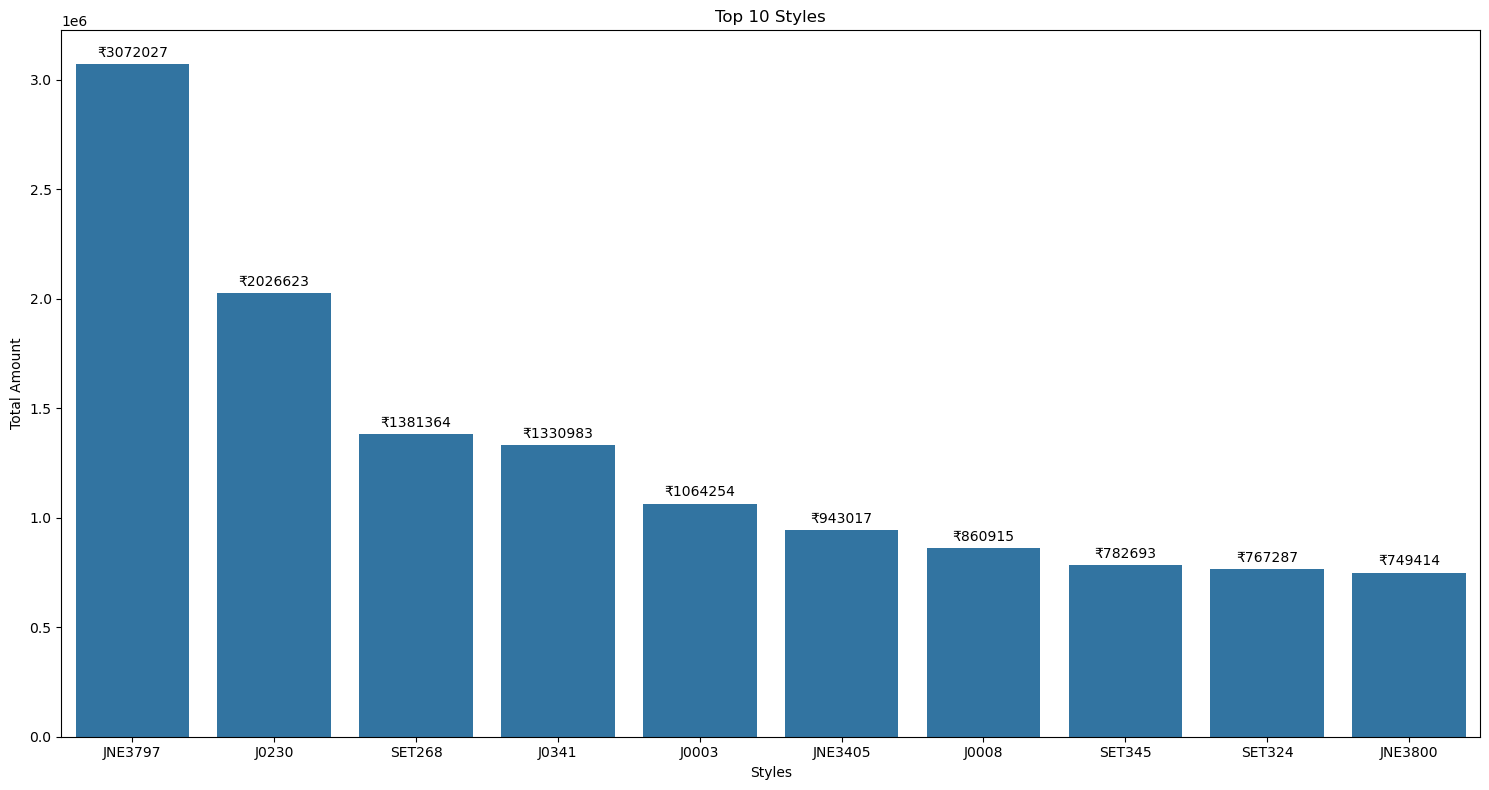

In [23]:
plt.figure(figsize=(15,8))
Style_Wise_Sales = df.groupby(['Style'], as_index=False)['Amount'].sum().sort_values(by= 'Amount', ascending=False).head(10)
ax = sns.barplot(x= 'Style', y= 'Amount', data= Style_Wise_Sales)
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding= 3)
plt.title('Top 10 Styles')
plt.xlabel('Styles')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

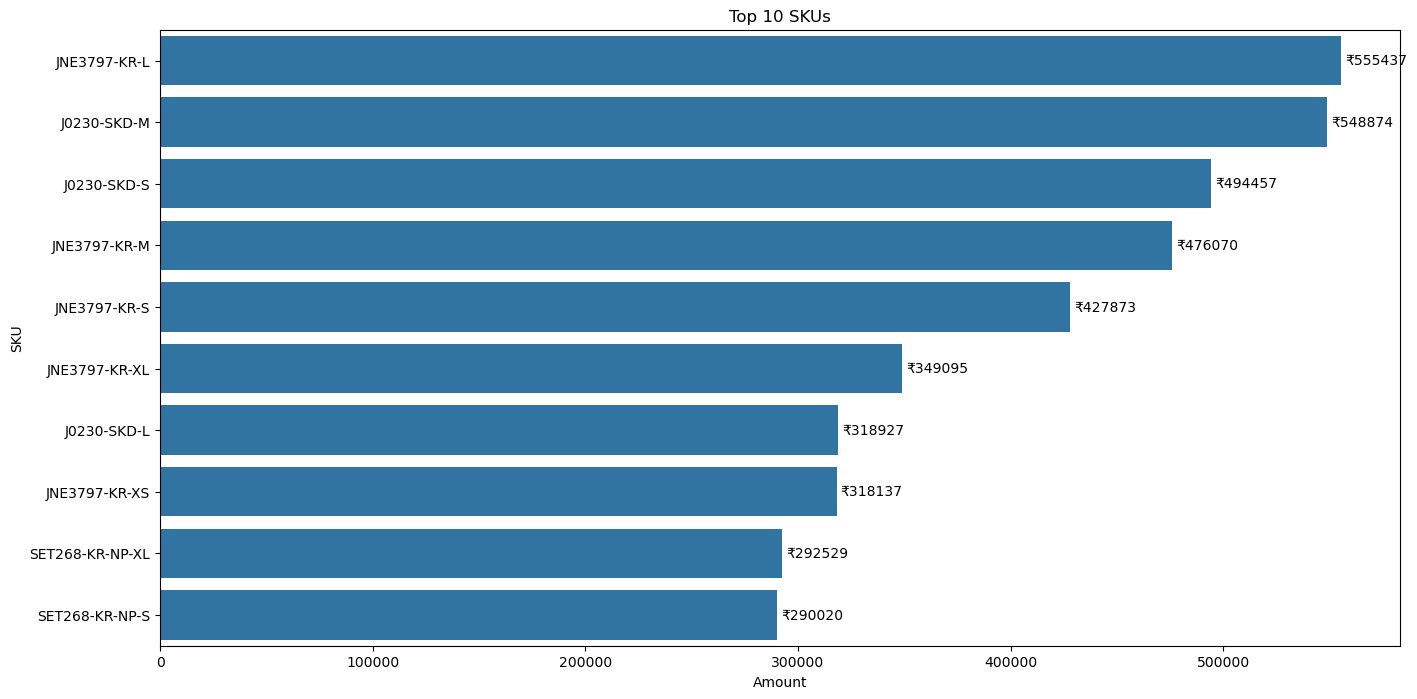

In [24]:
plt.figure(figsize=(16,8))
Top_10_SKUs = df.groupby(['SKU'], as_index= False)['Amount'].sum().sort_values(by = 'Amount', ascending=False).head(10)
ax = sns.barplot(x= 'Amount', y= 'SKU', data = Top_10_SKUs)
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding = 3)
plt.title('Top 10 SKUs')
plt.show()

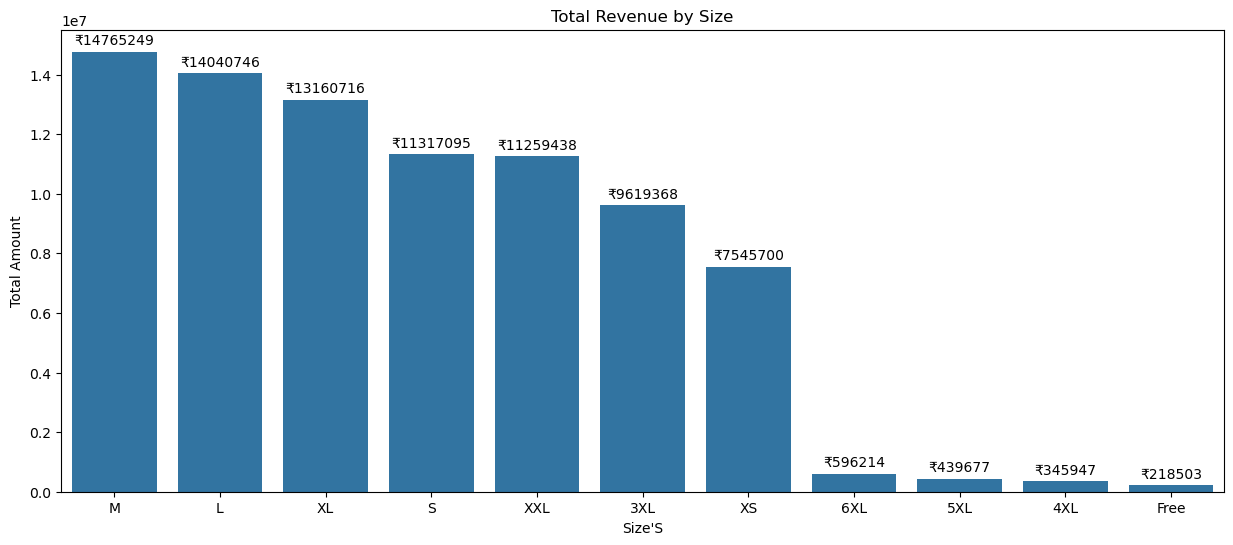

In [25]:
plt.figure(figsize=(15,6))
Total_revenue_by_size = df.groupby(['Size'], as_index=False)['Amount'].sum().sort_values(by= 'Amount', ascending =False)
ax = sns.barplot(x= 'Size', y= 'Amount', data = Total_revenue_by_size)
for container in ax.containers:
    ax.bar_label(container, fmt= '₹%.0f', padding = 3)
plt.title('Total Revenue by Size')
plt.xlabel('Size\'S')
plt.ylabel('Total Amount')
plt.show()

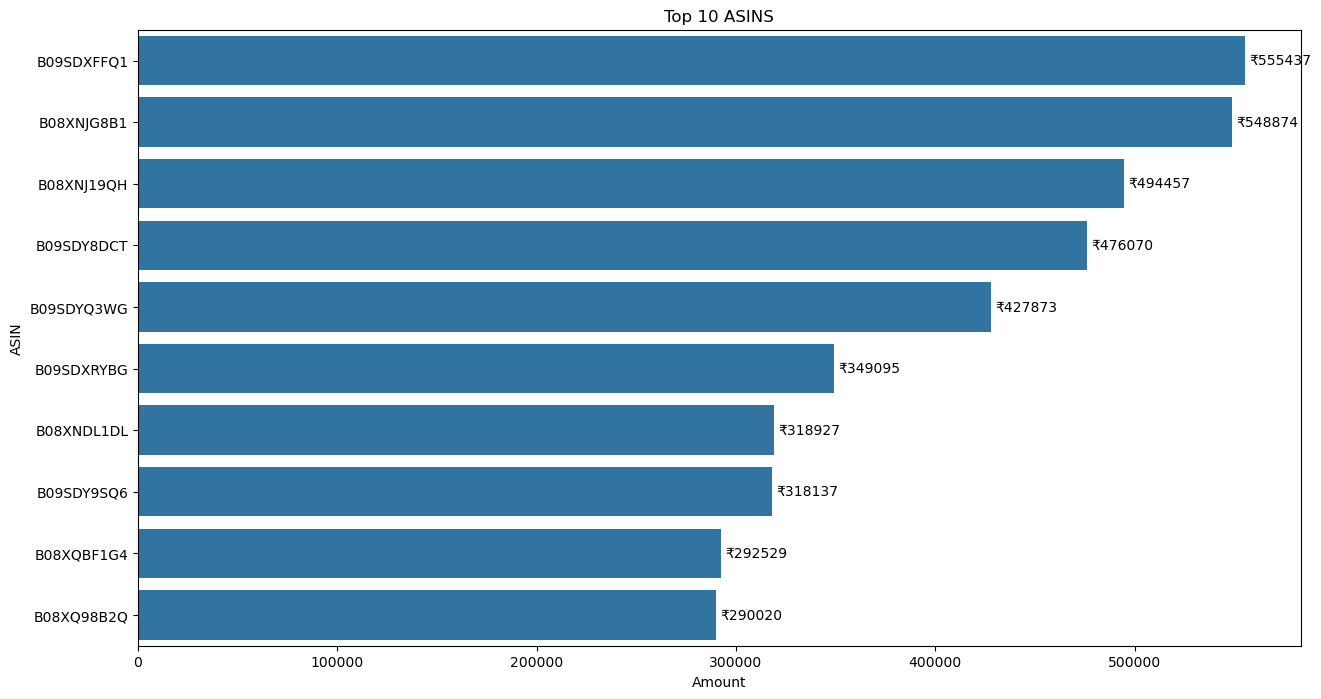

In [26]:
plt.figure(figsize= (15,8))
Top_10_ASIN = df.groupby(['ASIN'], as_index=False)['Amount'].sum().sort_values(by = 'Amount', ascending= False).head(10)
ax= sns.barplot(x= 'Amount', y= 'ASIN', data = Top_10_ASIN)
for container in ax.containers:
    ax.bar_label(container, fmt= '₹%.0f', padding = 3)
plt.title('Top 10 ASINS')
plt.show()

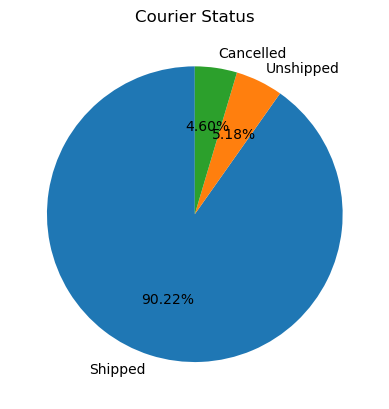

In [27]:
Courier_Status_Count = df['Courier Status'].value_counts()
plt.pie(
    Courier_Status_Count,
    labels = Courier_Status_Count.index,
    autopct= '%1.2f%%',
    startangle = 90
)
plt.title('Courier Status')
plt.show()

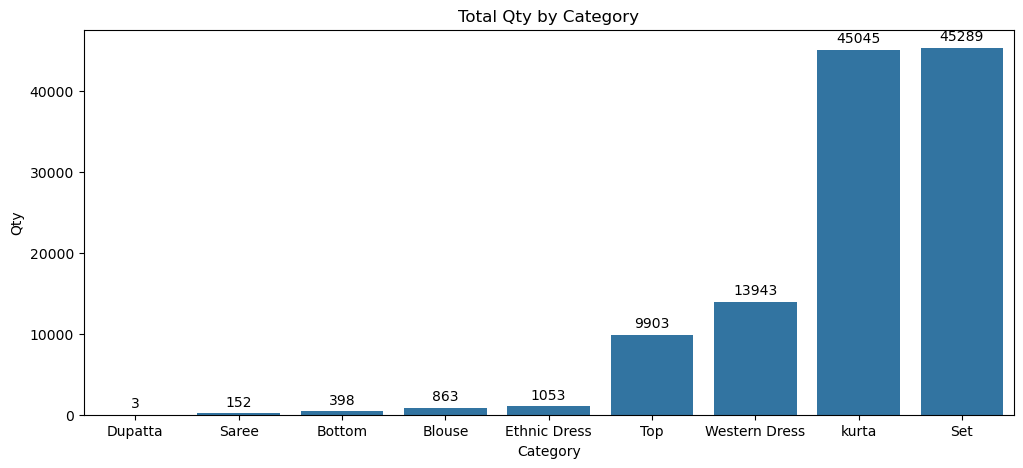

In [28]:
plt.figure(figsize=(12,5))
Category_by_QTY = df.groupby(['Category'], as_index=False)['Qty'].sum().sort_values(by= 'Qty', ascending= True)
ax = sns.barplot(x= 'Category', y= 'Qty', data= Category_by_QTY)
for container in ax.containers:
    ax.bar_label(container, fmt= '%.0f', padding= 3)
plt.title('Total Qty by Category')
plt.show()

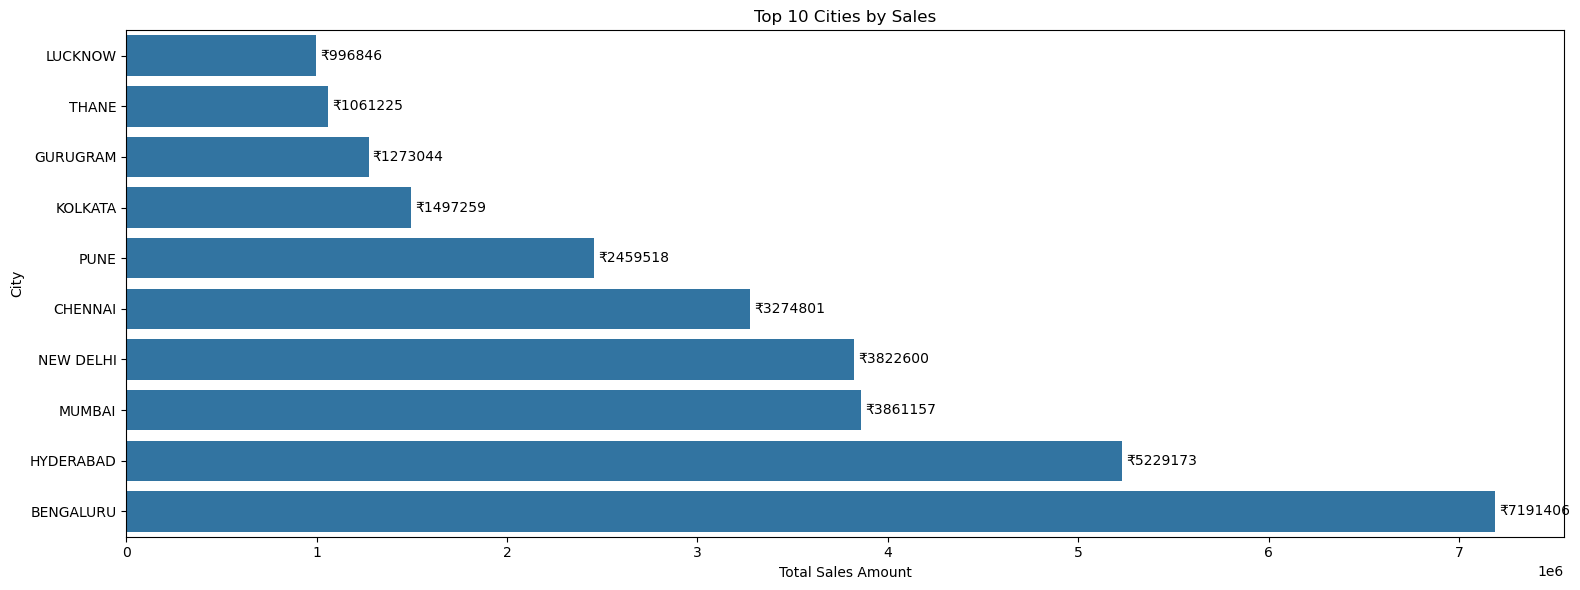

In [47]:
plt.figure(figsize=(16, 6))

cities_Amount = (df.groupby('ship-city', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=True).tail(10))

ax = sns.barplot(x='Amount',y='ship-city',data=cities_Amount)
for container in ax.containers:
    ax.bar_label(container,fmt='₹%.0f',padding=3)

plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales Amount')
plt.ylabel('City')
plt.tight_layout()
plt.show()

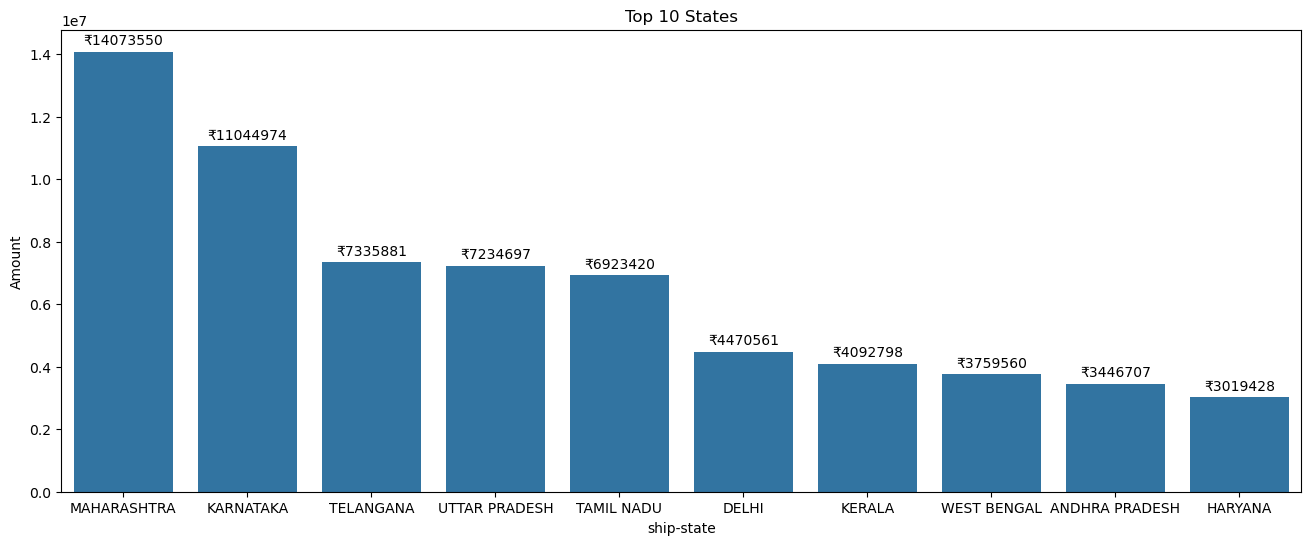

In [48]:
plt.figure(figsize=(16,6))
State_Amount= df.groupby(['ship-state'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False).head(10)
ax = sns.barplot(x= 'ship-state', y= 'Amount', data = State_Amount)
for container in ax.containers:
    ax.bar_label(container, fmt= '₹%.0f', padding= 3)
plt.title('Top 10 States')
plt.show()

In [49]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by',
       'ship_city_clean', 'ship_state_clean', 'Month'],
      dtype='object')

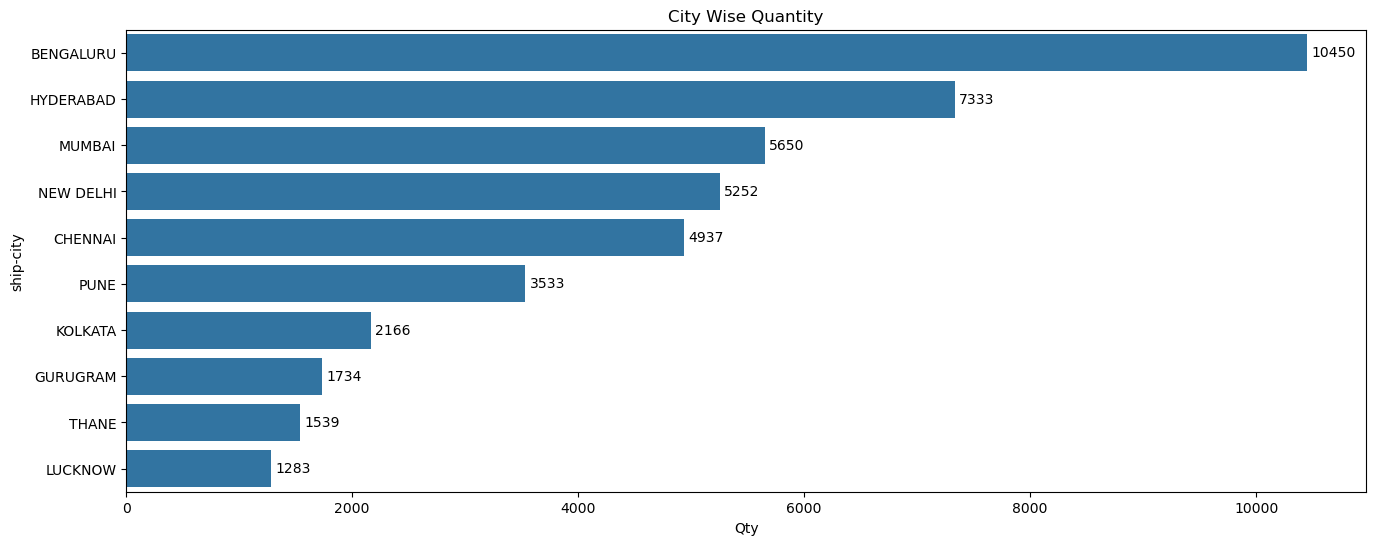

In [50]:
plt.figure(figsize=(16,6))
Cities_Qty = df.groupby(['ship-city'], as_index = False)['Qty'].sum().sort_values(by ='Qty', ascending=False).head(10)
ax = sns.barplot(x= 'Qty', y= 'ship-city', data = Cities_Qty)
for container in ax.containers:
    ax.bar_label(container, fmt= '%.0f', padding=3)
plt.title('City Wise Quantity')
plt.show()

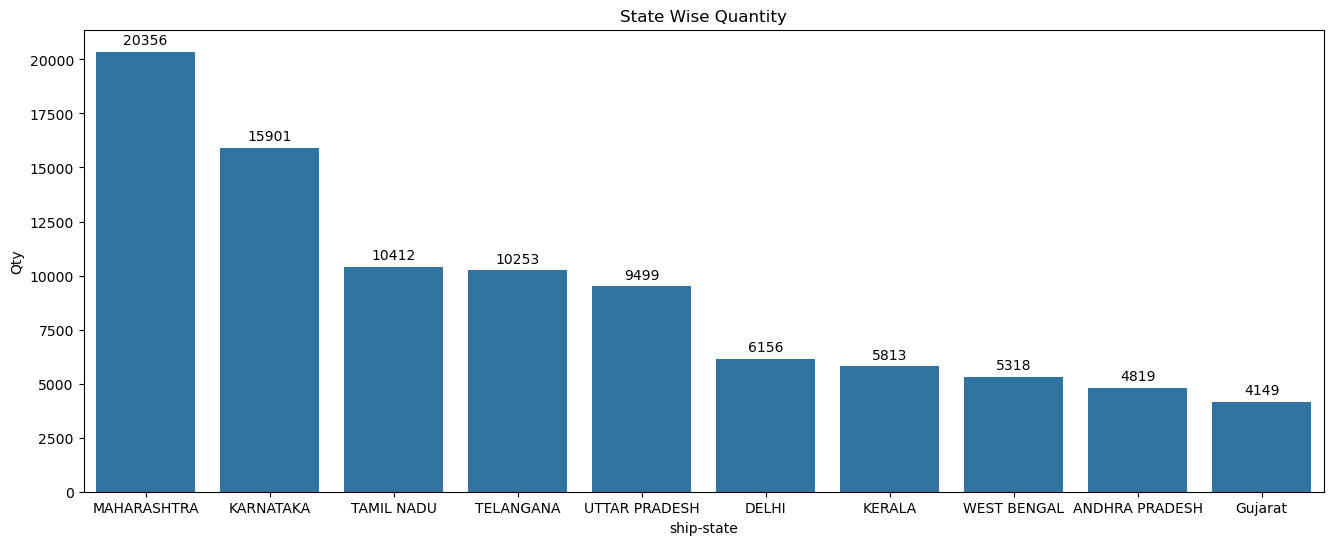

In [51]:
plt.figure(figsize=(16,6))
States_Qty = df.groupby(['ship-state'], as_index=False)['Qty'].sum().sort_values(by= 'Qty', ascending=False).head(10)
ax= sns.barplot(x= 'ship-state', y= 'Qty', data= States_Qty)
for container in ax.containers:
    ax.bar_label(container, fmt= '%.0f', padding=3)
plt.title('State Wise Quantity')
plt.show()